# Return curves of each option and env reward

In [3]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/g304pm83") 
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/4nimiw1j") 
# run = api.run("raban-emunds-tu-darmstadt/SymbolicOptions/runs/7vwud27u") 

In [4]:
import pandas as pd
import numpy as np


def get_algorithm_from_name(name):
    if "comb" in name:
        return "Soft meta-policy"
    elif "llm" in name:
        return "Fixed meta-policy"
    elif "pre" in name:
        return "Soft meta-policy with pretraining"
    elif "hier" in name:
        return "HPQN"
    if "pqn" in name:
        return "PQN"
    else:
        return "Unknown"

In [5]:

def get_run_data(runs, craftax=False):
    data = []
    for run in runs:
        run = api.run(runs[run])
        print("quering run: ", run.id)
        run_data= run.history()
        # run_data_full = run.history()
        seeds = list(set([key.split("/")[0] for key in run_data.keys() if "rng" in key]))
        # key_list = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "test/returned_episode_env_returns", "test_modif/returned_episode_env_returns"]
        # key_list = [seed + "/" + key for seed in seeds for key in key_list]
        # key_list.append("_step")
        # run_data = run_data_full.loc[:, key_list]

        x_data = run_data["_step"].to_numpy() / 1000
        def get_seed_data(seed):
            env_ret = run_data[seed + "/returned_episode_env_returns"].to_numpy()
            test_env_ret = run_data[seed + "/test/returned_episode_env_returns"].to_numpy()
            if not craftax:
                modif_test_env_ret = run_data[seed + "/test_modif/returned_episode_env_returns"].to_numpy()
            else:
                score = run_data[seed + "/score"].to_numpy()
                test_score = run_data[seed + "/test/score"].to_numpy()


            # opt_rets = {}
            opt_rets = []
            option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
            if craftax:
                option_strs += ["returned_episode_returns_3", "returned_episode_returns_4"]
            for opt_str in option_strs:
                ret = run_data[seed + "/" + opt_str].to_numpy()
                test_ret = run_data[seed + "/test/" + opt_str].to_numpy()
                if not craftax:
                    modif_test_ret = run_data[seed + "/test_modif/" + opt_str].to_numpy()
                    opt_rets += [ret, test_ret, modif_test_ret]
                else:
                    opt_rets += [ret, test_ret]
            if not craftax:
                return env_ret, test_env_ret, modif_test_env_ret, *opt_rets
            else:
                return env_ret, test_env_ret, score, test_score, *opt_rets
            
        all_data = np.array([get_seed_data(seed) for seed in seeds])

        if not craftax:
            row = {
                "run_id": run.id,
                "run_name": run.name,
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
                "opt0_ret": all_data[:, 3],
                "test_opt0_ret": all_data[:, 4],
                "modif_test_opt0_ret": all_data[:, 5],
                "opt1_ret": all_data[:, 6],
                "test_opt1_ret": all_data[:, 7],
                "modif_test_opt1_ret": all_data[:, 8],
                "opt2_ret": all_data[:, 9],
                "test_opt2_ret": all_data[:, 10],
                "modif_test_opt2_ret": all_data[:, 11],
            }
        else:
            row = {
                "run_id": run.id,
                "run_name": run.name,
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "score": all_data[:, 2],
                "test_score": all_data[:, 3],
                "opt0_ret": all_data[:, 4],
                "test_opt0_ret": all_data[:, 5],
                "opt1_ret": all_data[:, 6],
                "test_opt1_ret": all_data[:, 7],
                "opt2_ret": all_data[:, 8],
                "test_opt2_ret": all_data[:, 9],
                "opt3_ret": all_data[:, 10],
                "test_opt3_ret": all_data[:, 11],
                "opt4_ret": all_data[:, 12],
                "test_opt4_ret": all_data[:, 13],
            }

        data.append(row)
    df = pd.DataFrame(data)
    return df

# Seaquest 
seaquest_run_ids = {
    "pqn": "anikav8n",
    "hpqn": "9cot8a25",
    "llm": "ivxucgak",
    "comb": "wwaym6rm", # this is the new one
    # "comb": "nc3i9b6e", #TODO: change
    "comb_pre": "s9ode17q"
}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}
seaquest_df = get_run_data(seaquest_runs)

# Kangaroo 
kangaroo_run_ids = {
    "pqn": "g3fyf8qm",
    "hpqn": "jd7zgepa",
    "llm": "kk3s3oou",
    "comb": "5983jobq", 
    "comb_pre": "5whpom4g"
}

kangaroo_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in kangaroo_run_ids.items()
}

kangaroo_df = get_run_data(kangaroo_runs)

# craftax 
craftax_run_ids = {
    "pqn": "2sgxb9yv",
    "hpqn": "2oy51ht2",
    "llm": "7w8sbe6r",
    "comb": "90yv7key", 
    "comb_pre": "25ka3ljp"
}

craftax_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
}

craftax_df = get_run_data(craftax_runs, True)

quering run:  anikav8n
quering run:  9cot8a25
quering run:  ivxucgak
quering run:  wwaym6rm
quering run:  s9ode17q
quering run:  g3fyf8qm
quering run:  jd7zgepa
quering run:  kk3s3oou
quering run:  5983jobq
quering run:  5whpom4g
quering run:  2sgxb9yv
quering run:  2oy51ht2
quering run:  7w8sbe6r
quering run:  90yv7key
quering run:  25ka3ljp


In [6]:
craftax_df

,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,score,test_score,opt0_ret,test_opt0_ret,opt1_ret,test_opt1_ret,opt2_ret,test_opt2_ret,opt3_ret,test_opt3_ret,opt4_ret,test_opt4_ret
0,2sgxb9yv,pqn_Craftax-Classic-Symbolic-v1,[rng928981903],PQN,"[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, ...","[[0.01087188720703125, 0.01152648963034153, 0....","[[-0.9135290384292603, -0.9135290384292603, -0...","[[0.00565652921795845, 0.005833635572344065, 0...","[[0.002587670460343361, 0.002587670460343361, ...","[[-0.5063018798828125, -0.48230743408203125, -...","[[-72.54727935791016, -72.54727935791016, -72....","[[-0.02887725830078125, -0.02754974365234375, ...","[[-4.563838005065918, -4.563838005065918, -4.5...","[[0.0001983642578125, 0.00029754638671875, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0014514...","[[0.003326416015625, 0.00310516357421875, 0.00...","[[0.00312524801120162, 0.00312524801120162, 0....","[[0.004703903570771217, 0.004737091716378927, ...","[[0.08487507700920105, 0.08487507700920105, 0...."
1,2oy51ht2,pqn_hier_Craftax-Classic-Symbolic-v1,[rng928981903],HPQN,"[0.016, 0.03, 0.053, 0.087, 0.183, 0.196, 0.21...","[[0.009457397274672985, 0.008786773309111595, ...","[[1.2950799465179443, 1.2950799465179443, 1.29...","[[0.005089161917567253, 0.004734554328024387, ...","[[0.6977213025093079, 0.6977213025093079, 0.69...","[[-0.5293922424316406, -0.48764801025390625, -...","[[-71.9300537109375, -71.9300537109375, -71.93...","[[-0.0283966064453125, -0.026561737060546875, ...","[[-3.895700693130493, -3.895700693130493, -3.8...","[[0.00011444091796875, 9.918212890625e-05, 0.0...","[[0.01720619574189186, 0.01720619574189186, 0....","[[0.00321197509765625, 0.00278472900390625, 0....","[[0.4223554730415344, 0.4223554730415344, 0.42...","[[0.004713059403002262, 0.004340744577348232, ...","[[0.6460199952125549, 0.6460199952125549, 0.64..."
2,7w8sbe6r,pqn_hier_llm_Craftax-Classic-Symbolic-v1,[rng928981903],Fixed meta-policy,"[0.003, 0.004, 0.032, 0.047, 0.069, 0.096, 0.1...","[[0.009691620245575905, 0.00896606408059597, 0...","[[1.2950799465179443, 1.2950799465179443, 1.29...","[[0.005124733783304691, 0.004797870293259621, ...","[[0.6977213025093079, 0.6977213025093079, 0.69...","[[-0.5015144348144531, -0.5042610168457031, -0...","[[-71.9300537109375, -71.9300537109375, -71.93...","[[-0.026615142822265625, -0.027801513671875, -...","[[-3.895700693130493, -3.895700693130493, -3.8...","[[0.0001678466796875, 0.0001068115234375, 0.00...","[[0.01720619574189186, 0.01720619574189186, 0....","[[0.00318145751953125, 0.00281524658203125, 0....","[[0.4223554730415344, 0.4223554730415344, 0.42...","[[0.00446586636826396, 0.00464477576315403, 0....","[[0.6460199952125549, 0.6460199952125549, 0.64..."
3,90yv7key,pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1,[rng928981903],Soft meta-policy,"[0.018, 0.035, 0.037, 0.043, 0.068, 0.069, 0.1...","[[0.00954666081815958, 0.00909347552806139, 0....","[[1.2950799465179443, 1.2950799465179443, 1.29...","[[0.00509091280400753, 0.004836326465010643, 0...","[[0.6977213025093079, 0.6977213025093079, 0.69...","[[-0.5150070190429688, -0.49463653564453125, -...","[[-71.9300537109375, -71.9300537109375, -71.93...","[[-0.027492523193359375, -0.025485992431640625...","[[-3.895700693130493, -3.895700693130493, -3.8...","[[0.0001068115234375, 0.000152587890625, 8.392...","[[0.01720619574189186, 0.01720619574189186, 0....","[[0.0030975341796875, 0.00292205810546875, 0.0...","[[0.4223554730415344, 0.4223554730415344, 0.42...","[[0.00464325025677681, 0.004575729835778475, 0...","[[0.6460199952125549, 0.6460199952125549, 0.64..."
4,25ka3ljp,pqn_hier_llm_comb_pre_Craftax-Classic-Symbolic-v1,[rng928981903],Soft meta-policy,"[0.009, 0.02, 0.054, 0.063, 0.067, 0.069, 0.11...","[[0.009055327624082565, 0.00901946984231472, 0...","[[1.2950799465179443, 1.2950799465179443, 1.29...","[[0.004877638071775436, 0.0048376088961958885,...","[[0.6977213025093079, 0.6977213025093079, 0.69...","[[-0.50341796875, -0.48673248

In [7]:
# plot using plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from tueplots import bundles, axes
from matplotlib import cm

plt.rcParams.update({"figure.dpi": 150})


In [8]:
human_performance = {
    "Seaquest": 20182,
    "Kangaroo": 3035,
    "Craftax-Classic-Symbolic-v1": 50.5
}
# atari: https://training.incf.org/sites/default/files/2023-05/Human-level%20control%20through%20deep%20reinforcement%20learning.pdf
# crafter: https://github.com/danijar/crafter?tab=readme-ov-file

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


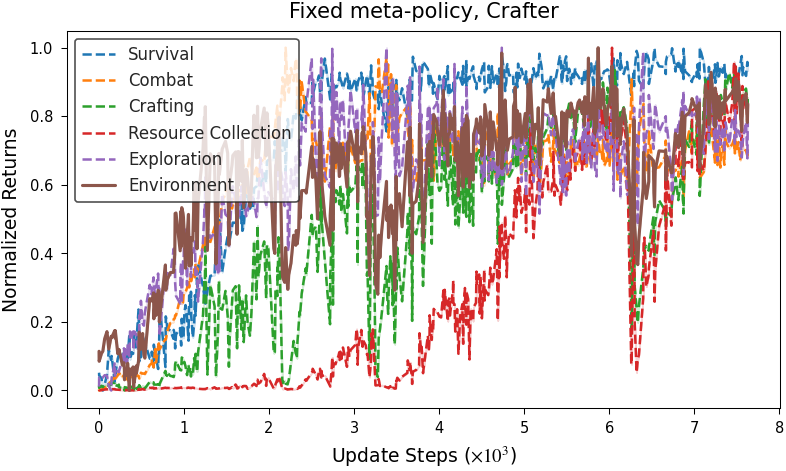

In [9]:
def single_run_plot(ax1, df, run_name, option_labels, game_name):
    # colors = cm.get_cmap("tab10")
    row = df[df["run_name"] == run_name].iloc[0]

    # sns.set_context("paper")
    sns.set_theme(context="paper", style="ticks")
    # colors = sns.color_palette("colorblind")
    colors = plt.cm.tab10.colors
    # with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    # fig, ax1 = plt.subplots()
    x_data = row["x_data"]
    eps = 1e-8
    for i, label in enumerate(option_labels):
        # normalize the data
        # option_mean = row[f"opt{i}_ret"].mean(axis=0) / row[f"opt{i}_ret"].mean(axis=0).max()
        stds = np.nanstd(row[f"opt{i}_ret"], axis=0) 
        means = np.nanmean(row[f"opt{i}_ret"], axis=0)
        # rescale
        option_stds = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + eps)
        option_means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + eps)
        ax1.plot(x_data, option_means, label=label, color=colors[i], zorder=1, linestyle="--")
        ax1.fill_between(x_data, option_means - option_stds, option_means + option_stds, color=colors[i], alpha=0.2, zorder=0)
    # ax1.set_xlabel("Update Steps ($\\times 10^3$)")
    # ax1.set_ylabel("Normalized Skill Returns")

    # Create a second y-axis for the environment reward
    # ax2 = ax1.twinx()
    # env_means = (row["env_ret"] - np.nanmean(row["env_ret"])) / np.nanstd(row["env_ret"])
    means = np.nanmean(row["env_ret"], axis=0)
    stds = np.nanstd(row["env_ret"], axis=0)
    # rescale
    env_means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + eps)
    env_std = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + eps)  
    # env_mean = np.nanmean(env_norm, axis=0)
    ax1.plot(x_data, env_means, label="Environment", color=colors[i+1], zorder=2, linewidth=1.5)
    ax1.fill_between(x_data, env_means - env_std, env_means + env_std, color=colors[i+1], alpha=0.2, zorder=0)
    # remove data from ax2
    # ax2.axhline(max(env_mean), color=colors[i+1], linestyle="--", alpha=1.0, zorder=1)
    # ax2.set_ylabel("Environment Return")
    
    # Combine legends from both axes and ensure they are drawn on top of the lines
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    # lines_2, labels_2 = ax2.get_legend_handles_labels()
    
    # set title
    ax1.set_title(f"{get_algorithm_from_name(run_name)}, {game_name}", fontsize=10)
    # legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2)#, ncol=2)
    # legend = ax1.legend(lines_2 + lines_1, labels_2 + labels_1)#, ncol=2)
    # legend.set_zorder(3)  # Ensure the legend is drawn on top of the lines
    
    # plt.title("Skill and Environment Returns")
    # plt.tight_layout()
    # plt.savefig(f"{run_name}_skills.pdf", bbox_inches="tight")
    # plt.show()
    return lines_1, labels_1 

with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    fig, ax1 = plt.subplots()
    handles, labels = single_run_plot(ax1, craftax_df, "pqn_hier_llm_Craftax-Classic-Symbolic-v1", ["Survival", "Combat", "Crafting", "Resource Collection", "Exploration"], "Crafter")
    plt.legend(handles, labels, loc="upper left", fontsize=8)
    plt.xlabel("Update Steps ($\\times 10^3$)")
    plt.ylabel("Normalized Returns")
    plt.tight_layout()
    plt.savefig("craftax_pqn_hier_llm_Craftax-Classic-Symbolic-v1.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


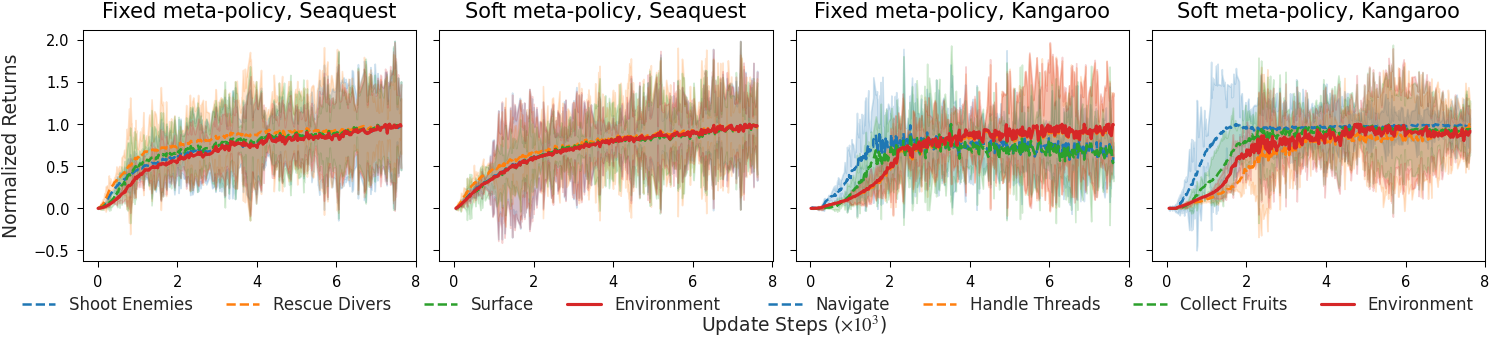

In [10]:

def plot_all_runs():
    with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
        fig, ax = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 2))

        runs = [
            (seaquest_df, "pqn_hier_llm_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (seaquest_df, "pqn_hier_comb_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (kangaroo_df, "pqn_hier_llm_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
            (kangaroo_df, "pqn_hier_comb_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
        ]
        handles, labels = [], []
        for i, (ax, (df, run_name, labels)) in enumerate(zip(ax.flatten(), runs)):
            name = run_name.split("_")[-1]
            h, l = single_run_plot(ax, df, run_name, labels, name)
            if i % 2 == 0:
                # fig.legend(unique.values(), unique.keys(), bbox_to_anchor=(0.5, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
                x = 0.25 if i == 0 else 0.75
                fig.legend(h, l, bbox_to_anchor=(x, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
        # Shared axis labels (only on the figure level)
        config = bundles.neurips2024(usetex=False)#["font"]
        # fig.supxlabel("Update Steps ($\\times 10^3$)", family=config["font.family"], size=config["font.size"])
        fig.supylabel("Normalized Returns", family=config["font.family"], size=config["font.size"])
        # fig.text(1, 0.5, "Environment Return", va="center", rotation=90, family=config["font.family"], size=config["font.size"]) 
        fig.text(0.47, -0.1, "Update Steps ($\\times 10^3$)", va="center", rotation=0, family=config["font.family"], size=config["font.size"]) 

        plt.savefig("skill_returns.pdf", bbox_inches="tight")
        plt.show()
plot_all_runs()
# TODO: two legends, equal y axis limits

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


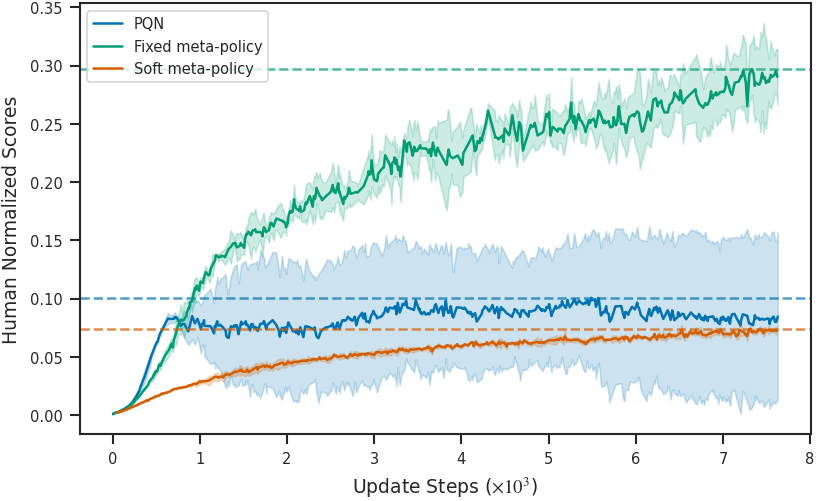

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


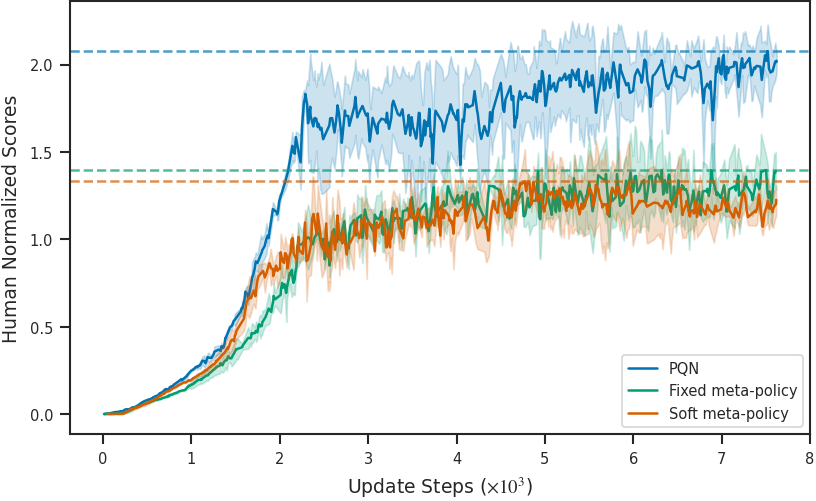

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


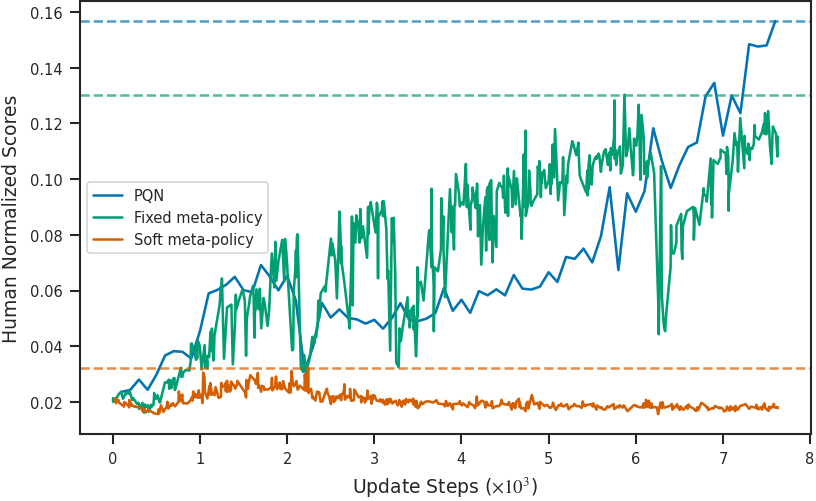

In [ ]:
def comparison_plot(df, perf_col, run_names):
    # Set the style
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # Create a figure and axis
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # Plot the data
        df1 = df[df["run_name"].isin(run_names)]
        for i, row in df1.iterrows():
            # ax.plot(row["env_ret"][0], label=row["algorithm"], color=colors(i), zorder=1)
            # ax.axhline(row["env_ret"][0].max(), color=colors(i), linestyle="--", alpha=0.7, zorder=1)
            # use plt to plot data across multiple seeds
            step = row["x_data"]
            mean = np.mean(row[perf_col], axis=0)
            std = np.std(row[perf_col], axis=0)
            game_name = row["run_name"].split("_")[-1]
            if "Craft" in game_name:
                mean *= (7.9 / 0.0375) # since max test score is 7.9 and max train score is 0.0375 (TODO: check this)
                std *= (7.9 / 0.0375)
            if game_name in human_performance:
                human_mean = human_performance[game_name] 
                mean = mean / human_mean
                std = std / human_mean
            # if "Craftax" in run_names[0]:
            #     mean = np.mean(row["test_score"], axis=0)
            #     std = np.std(row["test_score"], axis=0)
            ax.plot(step, mean, label=row["algorithm"], color=colors[i], zorder=1)
            ax.fill_between(step, mean - std, mean + std, alpha=0.2, color=colors[i], zorder=1)
            ax.axhline(mean.max(), color=colors[i], linestyle="--", alpha=0.7, zorder=1)

        # Set the labels and title
        ax.set_xlabel("Update Steps ($\\times 10^3$)") 
        ax.set_ylabel("Human Normalized Score")
        # if "Craftax" in run_names[0]:
        #     ax.set_ylabel("Test Score")
        # Add a legend
        ax.legend()
        # Show the plot
        # plt.tight_layout()
        name = run_names[0].split("_")[-1]
        plt.savefig(f"{name}_comparison.pdf", bbox_inches="tight")
        plt.show()
# comparison_plot(seaquest_df, ["pqn_Seaquest", "pqn_hier_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
# comparison_plot(kangaroo_df, ["pqn_Kangaroo", "pqn_hier_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
# comparison_plot(craftax_df, ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])
comparison_plot(seaquest_df, "env_ret", ["pqn_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
comparison_plot(kangaroo_df, "env_ret", ["pqn_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
comparison_plot(craftax_df, "score", ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


20182
[2050.55171712 5235.64518229 1384.70186361]
(3,)
(3,)
[0 1 2] 0 0.2 [0. 1. 2.]
20182
[    0.         13564.44856771  3924.28104655]
(3,)
(3,)
[0 1 2] 1 0.2 [0.2 1.2 2.2]
3035
[11300.          3860.51123047  3984.36450195]
(3,)
(3,)
[0 1 2] 2 0.2 [0.4 1.4 2.4]
3035
[ 300.         1330.97098796  500.32552083]
(3,)
(3,)
[0 1 2] 3 0.2 [0.6 1.6 2.6]


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


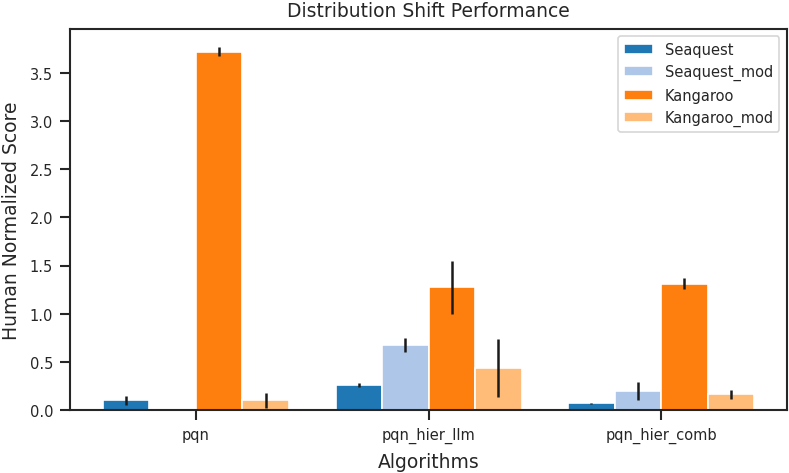

In [55]:
# What about distribution shifts? How do they handle them?

def extract_performance(df, performance_col, games, algos):
    # in the end, i want (n_algos, n_envs*2) matrix with best performance (and std)
    data = []
    data_std = []
    for algo in algos:
        algo_data = []
        algo_data_std = []
        for game in games:
            # get the run with the maximum environment performance
            non_mod = df[df["run_name"] == f"{algo}_{game}"][f"{performance_col}"].iloc[0]
            # replace nans with median
            non_mod = np.nan_to_num(non_mod, nan=np.nanmedian(non_mod))
            max_idx = np.nanmean(non_mod, axis=0).argmax() # (1,)

            mod = df[df["run_name"] == f"{algo}_{game}"][f"modif_{performance_col}"].iloc[0]
            mod = np.nan_to_num(mod, nan=np.nanmedian(mod))

            algo_data.append(np.nanmean(non_mod, axis=0)[max_idx])
            algo_data.append(np.nanmean(mod, axis=0)[max_idx])
            algo_data_std.append(np.nanstd(non_mod, axis=0)[max_idx])
            algo_data_std.append(np.nanstd(mod, axis=0)[max_idx])
        data.append(algo_data)
        data_std.append(algo_data_std)
    data = np.array(data)
    data_std = np.array(data_std)
    return data.T, data_std.T


def distribution_shift_plot(data, data_std, games, algos,x_axis='algos'):
    sns.set_theme(context="paper", style="ticks")
    # colors = sns.color_palette("colorblind")
    colors = plt.cm.tab20.colors
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        if x_axis == 'games':
            x = np.arange(len(games))
        else:
            x = np.arange(len(algos))
        # x = np.arange(len(algos))  # label locations
        width = 0.2
        if x_axis == 'games':
            ys = algos
        else:
            ys = games
        for i, y in enumerate(ys):
            # get the data for the game
            y_data = data[i]
            y_std = data_std[i]
            game = games[i] if x_axis != 'games' else games[i%len(games)]
            base_game = lambda g: g.split("_")[0]
            human_score = human_performance[base_game(games[i])] if x_axis == 'algos' else [human_performance[base_game(g)] for g in games]
            print(human_score)
            print(y_data)
            y_data = y_data / human_score
            y_std = y_std / human_score
            print(y_data.shape)
            print(y_std.shape)
            print(x, i , width, (x+i * width))
            # plot the data
            ax.bar(x + i * width, y_data, width, label=y, yerr=y_std, color=colors[i])

        ax.set_ylabel("Human Normalized Score")
        ax.set_xticks(x + width*1.5)
        ax.legend()
        xlabel = "Games" if x_axis == 'games' else "Algorithms"
        ax.set_xlabel(xlabel)
        ax.set_xticklabels(games if x_axis == 'games' else algos)
        ax.set_title("Distribution Shift Performance")
        plt.tight_layout()
        plt.savefig("distribution_shift.pdf", bbox_inches="tight")
        plt.show()

seaquest_df["game"] = "Seaquest"
kangaroo_df["game"] = "Kangaroo"
both_df = pd.concat([seaquest_df, kangaroo_df], ignore_index=True)
data, data_std = extract_performance(both_df, "test_env_ret", ["Seaquest", "Kangaroo"], ["pqn", "pqn_hier_llm", "pqn_hier_comb"])
# shape of data is (n_envs, n_algos)
# For x-axis=games:
# data = data.T
# data_std = data_std.T
distribution_shift_plot(data, data_std, ["Seaquest", "Seaquest_mod", "Kangaroo", "Kangaroo_mod"], ["pqn", "pqn_hier_llm", "pqn_hier_comb"], x_axis="algos")


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


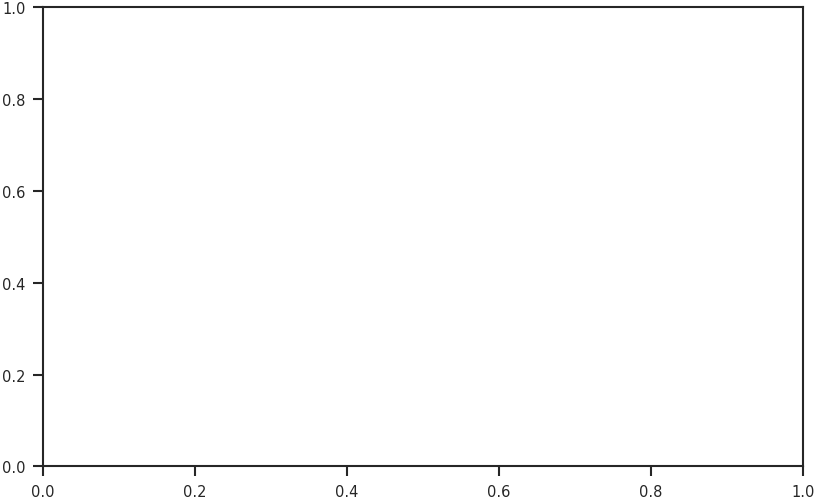

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


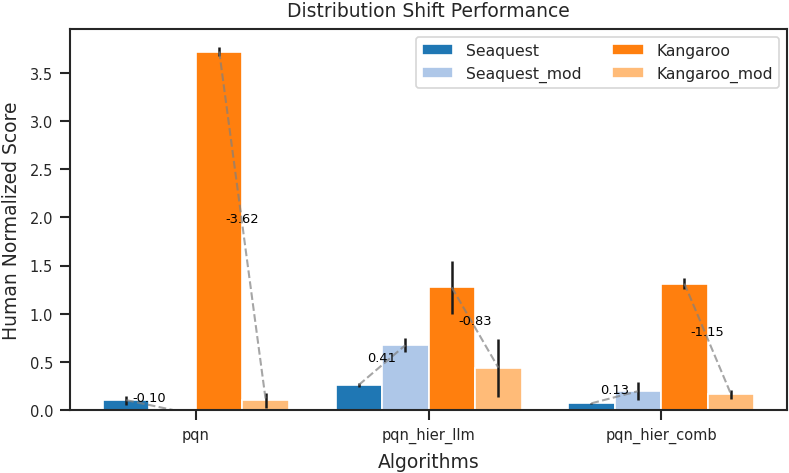

In [ ]:
def distribution_shift_plot2(data, data_std, games, algos, x_axis='algos'):
    sns.set_theme(context="paper", style="ticks")
    colors = plt.cm.tab20.colors

    # Helper to normalize raw scores by human baseline
    def normalize_by_human(raw):
        base_game = lambda g: g.split("_")[0]
        human_scores = [human_performance[base_game(g)] for g in games]
        return raw / np.array(human_scores)[:, None]

    norm_data = normalize_by_human(data)
    norm_std  = normalize_by_human(data_std)

    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # positions for each algorithm (or game)
        x = np.arange(len(algos)) if x_axis == 'algos' else np.arange(len(games))
        width = 0.2

        # draw bars
        for i, game in enumerate(games):
            ax.bar(
                x + i * width,
                norm_data[i],
                width,
                label=game,
                yerr=norm_std[i],
                color=colors[i]
            )

        # connection lines + annotations
        pairs = [("Seaquest", "Seaquest_mod"), ("Kangaroo", "Kangaroo_mod")]
        idx = {g: i for i, g in enumerate(games)}

        for algo_idx in range(len(algos)):
            for orig, mod in pairs:
                i0, i1 = idx[orig], idx[mod]
                # bar centers
                x0 = x[algo_idx] + i0 * width
                x1 = x[algo_idx] + i1 * width
                # heights
                y0 = norm_data[i0, algo_idx]
                y1 = norm_data[i1, algo_idx]
                # draw dashed connector
                ax.plot([x0, x1], [y0, y1],
                        linestyle='--', linewidth=1,
                        color='gray', alpha=0.7)
                # compute and annotate change (mod - orig)
                delta = y1 - y0
                xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                ax.text(xm, ym + 0.01,  # offset label slightly above line
                        f"{delta:.2f}",
                        ha='center', va='bottom',
                        fontsize='x-small', color='black')

        # labels, ticks, legend
        ax.set_ylabel("Human Normalized Score")
        ax.set_xlabel("Algorithms" if x_axis == 'algos' else "Games")
        ax.set_xticks(x + width * (len(games) - 1) / 2)
        ax.set_xticklabels(algos if x_axis == 'algos' else games)
        ax.set_title("Distribution Shift Performance")
        ax.legend(ncol=2, fontsize='small')
        plt.tight_layout()
        plt.savefig("distribution_shift_with_deltas.pdf", bbox_inches="tight")
        plt.show()
distribution_shift_plot2(data, data_std, ["Seaquest", "Seaquest_mod", "Kangaroo", "Kangaroo_mod"], ["pqn", "pqn_hier_llm", "pqn_hier_comb"], x_axis="algos")